# Problem D: Prediction of Traffic Flow based on Burgers’ Equation Model

Burgers' equation is a classical PDE model that captures the interplay between nonlinear convection and diffusion, making it well-suited for describing traffic flow dynamics. In this context, the convective term models the tendency for traffic to compress as vehicle density increases, while the diffusive term reflects the smoothing effect of individual driver reactions to surrounding traffic conditions.

The viscous Burgers' equation governing the evolution of vehicle velocity is:

$$
u_t + uu_x = \nu u_{xx}, \qquad x\in(-1,1),\ t\in(0,1] \tag{3}
$$

where:
- $u(x,t)$: vehicle velocity field (m/s),
- $\nu = 0.1/\pi$: kinematic viscosity coefficient (a higher value reflects more cautious, diffusive driver behavior),
- $x$: position along the road segment,
- $t$: time.

Homogeneous Dirichlet boundary conditions are imposed at both ends of the road:

$$
u(-1,\, t) = u(1,\, t) = 0, \qquad t \in (0, 1]
$$

Given an initial velocity profile $u(x, 0) = a(x)$, the full spatio-temporal velocity field $u(x,t)$ for $t > 0$ is uniquely determined by solving Eq. (3). In practice, however, running a high-fidelity finite difference solver for every new initial condition is computationally prohibitive. The goal of this task is therefore to learn a fast surrogate that approximates the solution operator $a(x) \mapsto u(x,t)$.

## Task: predicting the velocity filed $u(x,t)$ given the inital field $a(x)$ 

A dataset of initial conditions $a(x)$ sampled from a distribution $\mathcal{A}$ has been collected, along with the corresponding velocity fields $u(x,t)$ computed by a high-precision Finite Difference Method (FDM) solver. The dataset is **partially labeled**: only a small subset of initial conditions is paired with its FDM solution, while a much larger set of initial conditions has no corresponding solution available. This reflects a realistic scenario in which high-fidelity simulation data is scarce and expensive to obtain. The trained surrogate model should accurately predict $u(x,t)$ for any new initial condition $a(x)$ drawn from the same distribution $\mathcal{A}$, at negligible computational cost.

### Goals

- Select a suitable deep learning method for this task and justify your choice. 
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The error is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\displaystyle\sum_i\left|u^{(j)}_{\text{pred}}(x_i,t_i)-u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}{\displaystyle\sum_i\left|u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatio-temporal grid point.

- For the **first test instance**, use `matplotlib` to produce four separate figures:
  1. The initial condition $a(x) = u(x, 0)$
  2. The predicted velocity field $u_{\text{pred}}(x,t)$
  3. The ground truth velocity field $u_{\text{true}}(x,t)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

All data are provided in `ProblemD_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train_labeled` | (200, 256) | $N=200$ **labeled** initial fields, sampled at 256 spatial sensors |
| `u_train_labeled` | (200, 200, 256) | Corresponding FDM-computed velocity fields on a $200\times256$ spatio-temporal grid |
| `a_train_unlabeled` | (1800, 256) | $N=1800$ **unlabeled** initial fields (no paired solution available) |
| `a_test` | (200, 256) | Test initial conditions (**do not use for training**) |
| `u_test` | (200, 200, 256) | Ground truth velocity fields for test instances (**do not use for training**) |
| `x_mesh` | (256, 1) | Spatial coordinates of the 256 grid points |
| `t_mesh` | (200, 1) | Temporal coordinates of the 200 time steps |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['a_test', 'a_train_labeled', 'a_train_unlabeled', 't_mesh', 'u_test', 'u_train_labeled', 'x_mesh']>
t_mesh: torch.Size([200, 1]) x_mesh: torch.Size([256, 1])
a_train_labeled: torch.Size([200, 256]) u_train_labeled: torch.Size([200, 200, 256])
a_train_unlabeled: torch.Size([1800, 256])
a_test: torch.Size([200, 256]) u_test: torch.Size([200, 200, 256])


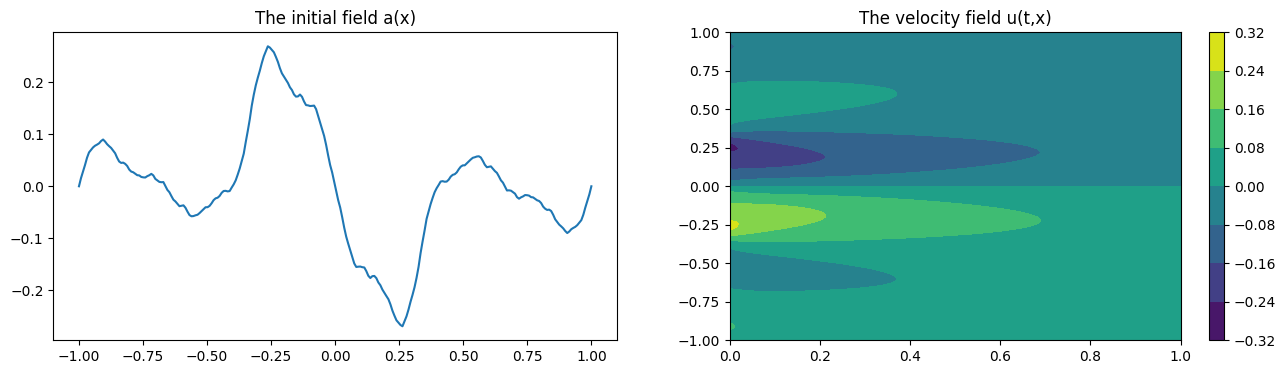

In [3]:
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
dtype = torch.float32
######################################
# Load training data
######################################
with h5py.File('ProblemD_dataset.h5', 'r') as file:
    print(file.keys())
    t_mesh = torch.tensor(np.array(file['t_mesh']), dtype=dtype)
    x_mesh = torch.tensor(np.array(file['x_mesh']), dtype=dtype)
    a_test = torch.tensor(np.array(file['a_test']), dtype=dtype)
    u_test = torch.tensor(np.array(file['u_test']), dtype=dtype)
    a_train_labeled = torch.tensor(np.array(file['a_train_labeled']), dtype=dtype)
    u_train_labeled = torch.tensor(np.array(file['u_train_labeled']), dtype=dtype)
    a_train_unlabeled = torch.tensor(np.array(file['a_train_unlabeled']), dtype=dtype)
    #
    X, T = np.meshgrid(x_mesh, t_mesh)
#
print('t_mesh:', t_mesh.shape, 'x_mesh:', x_mesh.shape)
print('a_train_labeled:', a_train_labeled.shape, 'u_train_labeled:', u_train_labeled.shape)
print('a_train_unlabeled:', a_train_unlabeled.shape)
print('a_test:', a_test.shape, 'u_test:', u_test.shape)
#################################
inx = 0
fig, axes = plt.subplots(1,2, figsize=(16,4))
#
cntr = axes[0].plot(x_mesh, a_train[0])
axes[0].set_title('The initial field a(x)')
#
cntr = axes[1].contourf(T, X, u_train[inx])
axes[1].set_title('The velocity field u(t,x)')
plt.colorbar(cntr)
#
plt.show()